In [1]:
import torch
import pandas as pd
from epiweeks import Week
import sys
import preprocess_data as prep
import matplotlib.pyplot as plt 
from mosqlient.scoring import Scorer


pd.options.mode.chained_assignment = None

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

regioes_estados = {
        'Sul': ['SC', 'PR', 'RS'],
        'Sudeste': ['SP', 'MG', 'RJ', 'ES'],
        'Nordeste': ['BA', 'CE', 'PE', 'PB', 'PI', 'RN', 'MA', 'AL', 'SE'],
        'Centro-Oeste': ['DF', 'MT', 'MS', 'GO'],
        'Norte': ['RO', 'AC', 'AM', 'RR', 'PA', 'AP', 'TO']
    } 
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


columns_to_normalize_enso = ['casos','epiweek', 'biome', 'enso']

columns_to_normalize = ['casos','epiweek', 'biome']

predict_n = 36
max_epiweek = 16
    
boxcox = False

TEST_YEAR = 2023

In [2]:
media = True
min_year = 2015
doenca = 'chikungunya'
#model_name = 'enso'

enso = prep.load_enso_weekly()
df = prep.load_cases_data(filename= f'./data/{doenca}.csv.gz')

In [5]:
from pathlib import Path

def make_pred(
    df_reg_agg,
    df_reg,
    enso,
    doenca,
    region,
    TEST_YEAR,
    columns_to_normalize,
    model_name,
    media=True
):

    pred_path = Path(
        f"predictions/preds_{doenca}_{region}_{TEST_YEAR}_{model_name}.csv"
    )


    print(f"Loading {pred_path}")

    df_preds1 = pd.read_csv(
            pred_path,
            index_col=0,
            parse_dates=True
        )

    df_preds1.date = pd.to_datetime(df_preds1.date)

    score = Scorer(
        api_key='',
        df_true=df_reg_agg,
        pred=df_preds1,
    )

    mean_sc1 = score.wis[1]['pred']

    return df_preds1, mean_sc1



Sul
Loading predictions/preds_chikungunya_Sul_2023_base.csv
Loading predictions/preds_chikungunya_Sul_2023_enso_media.csv
Loading predictions/preds_chikungunya_Sul_2023_dengue_base.csv
Loading predictions/preds_chikungunya_Sul_2023_dengue_enso_media.csv


/tmp/ipykernel_61701/1840567461.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(
/tmp/ipykernel_61701/1840567461.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(
/tmp/ipykernel_61701/1840567461.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(
/tmp/ipykernel_61701/1840567461.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(


Loading predictions/preds_chikungunya_Sul_2023_dengue_mix.csv


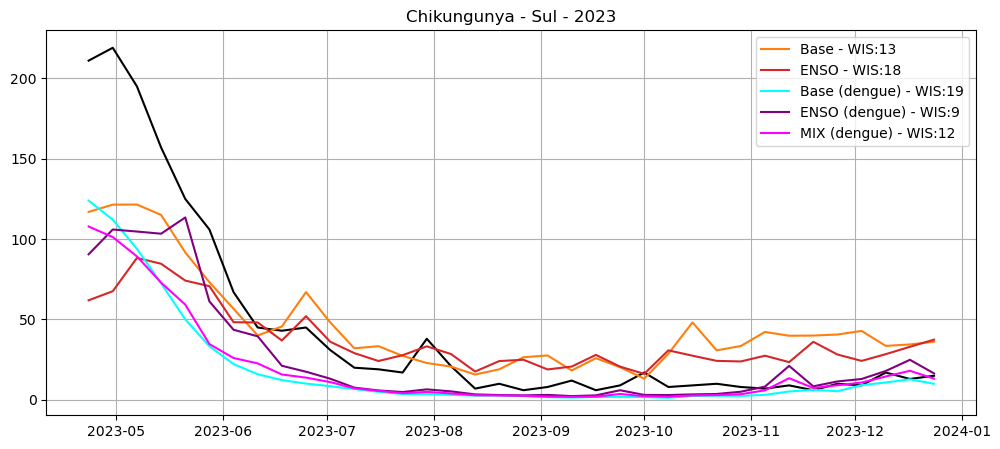

Sudeste
Loading predictions/preds_chikungunya_Sudeste_2023_base.csv
Loading predictions/preds_chikungunya_Sudeste_2023_enso_media.csv
Loading predictions/preds_chikungunya_Sudeste_2023_dengue_base.csv


/tmp/ipykernel_61701/1840567461.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(
/tmp/ipykernel_61701/1840567461.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(
/tmp/ipykernel_61701/1840567461.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(
/tmp/ipykernel_61701/1840567461.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(


Loading predictions/preds_chikungunya_Sudeste_2023_dengue_enso_media.csv
Loading predictions/preds_chikungunya_Sudeste_2023_dengue_mix.csv


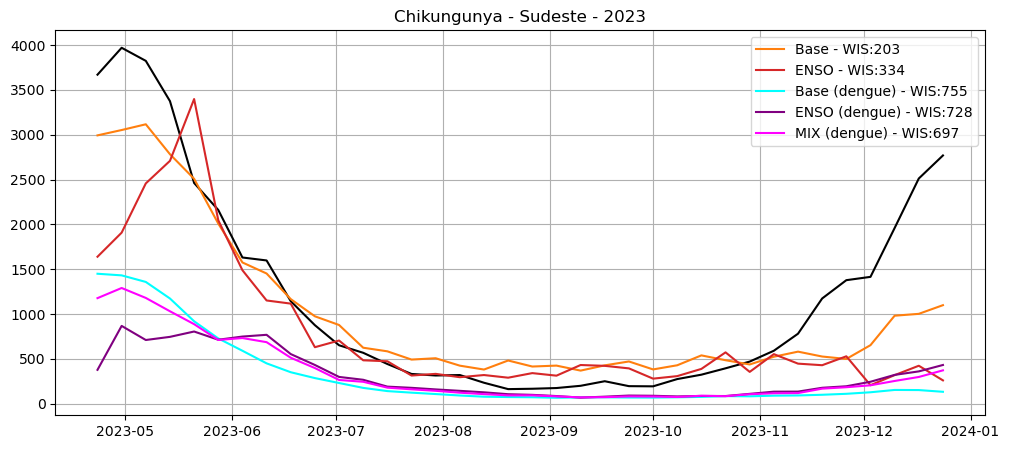

Nordeste
Loading predictions/preds_chikungunya_Nordeste_2023_base.csv
Loading predictions/preds_chikungunya_Nordeste_2023_enso_media.csv


/tmp/ipykernel_61701/1840567461.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(
/tmp/ipykernel_61701/1840567461.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(
/tmp/ipykernel_61701/1840567461.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(
/tmp/ipykernel_61701/1840567461.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(


Loading predictions/preds_chikungunya_Nordeste_2023_dengue_base.csv
Loading predictions/preds_chikungunya_Nordeste_2023_dengue_enso_media.csv
Loading predictions/preds_chikungunya_Nordeste_2023_dengue_mix.csv


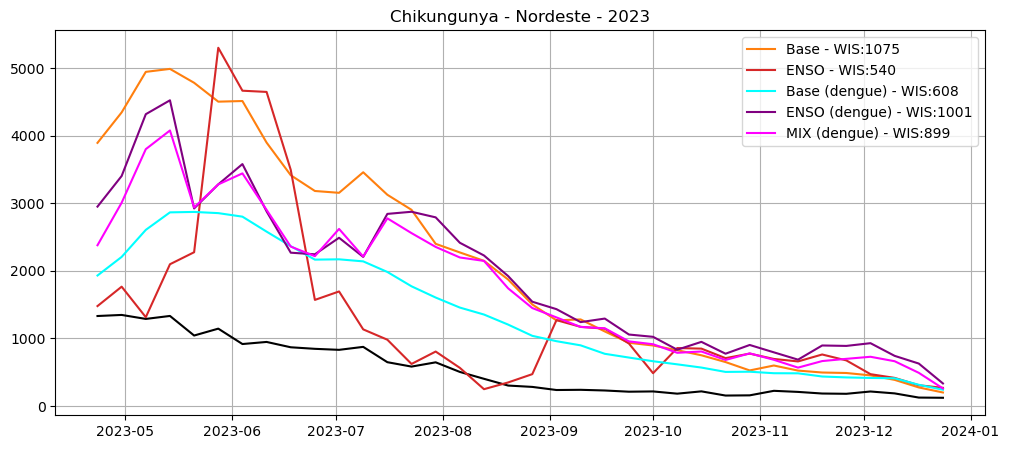

Centro-Oeste
Loading predictions/preds_chikungunya_Centro-Oeste_2023_base.csv
Loading predictions/preds_chikungunya_Centro-Oeste_2023_enso_media.csv
Loading predictions/preds_chikungunya_Centro-Oeste_2023_dengue_base.csv
Loading predictions/preds_chikungunya_Centro-Oeste_2023_dengue_enso_media.csv
Loading predictions/preds_chikungunya_Centro-Oeste_2023_dengue_mix.csv


/tmp/ipykernel_61701/1840567461.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(
/tmp/ipykernel_61701/1840567461.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(
/tmp/ipykernel_61701/1840567461.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(
/tmp/ipykernel_61701/1840567461.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(


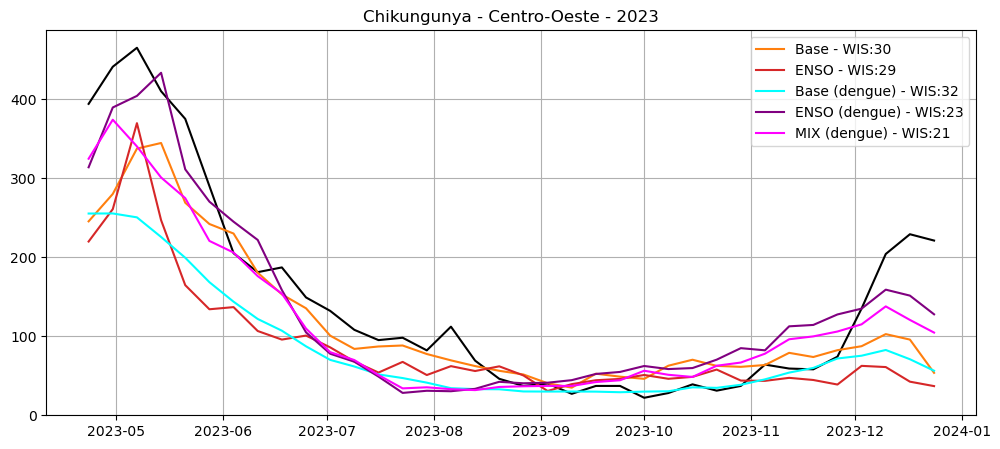

Norte
Loading predictions/preds_chikungunya_Norte_2023_base.csv
Loading predictions/preds_chikungunya_Norte_2023_enso_media.csv
Loading predictions/preds_chikungunya_Norte_2023_dengue_base.csv
Loading predictions/preds_chikungunya_Norte_2023_dengue_enso_media.csv
Loading predictions/preds_chikungunya_Norte_2023_dengue_mix.csv


/tmp/ipykernel_61701/1840567461.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(
/tmp/ipykernel_61701/1840567461.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(
/tmp/ipykernel_61701/1840567461.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(
/tmp/ipykernel_61701/1840567461.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(


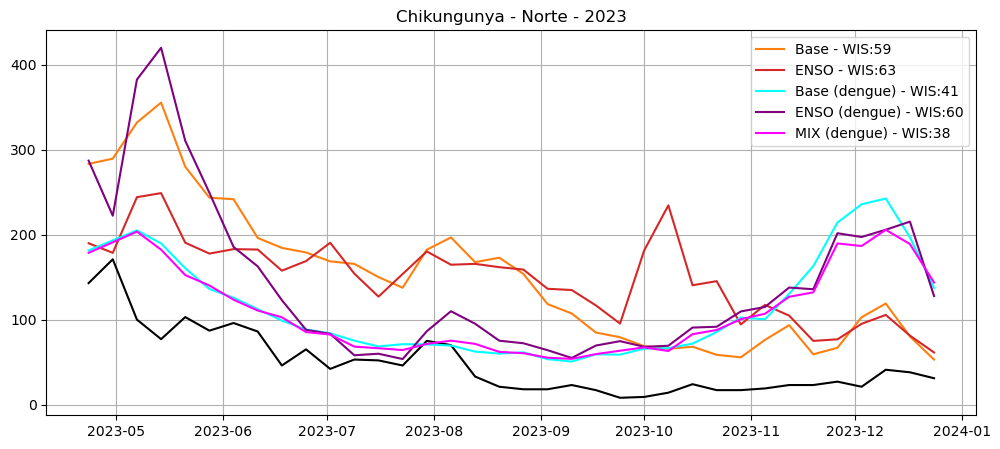

4

In [6]:
for region in regioes_estados.keys(): 

    print(region)

    df_reg = df.loc[df.uf.isin(regioes_estados[region])]
    df_reg = df_reg.loc[df_reg.index >= pd.to_datetime(Week(2015,1).startdate())]

    df_reg_agg = df_reg.groupby(['date', 'epiweek'])[['casos']].sum().reset_index()
    df_reg_agg = df_reg_agg.loc[(df_reg_agg.epiweek >= int(f'{TEST_YEAR}17')) & (df_reg_agg.epiweek <= int(f'{TEST_YEAR}52'))]

    df_preds1, mean_sc1 = make_pred(df_reg_agg, df_reg, None, doenca, region, TEST_YEAR, columns_to_normalize, model_name = 'base', media = True )

    df_preds2, mean_sc2 = make_pred(df_reg_agg, df_reg, enso, doenca, region, TEST_YEAR, columns_to_normalize_enso, model_name = 'enso_media', media = True )

    #df_preds3, mean_sc3 = make_pred(df_reg_agg, df_reg, enso, doenca, region, TEST_YEAR, columns_to_normalize_enso, model_name = 'mix', media = True )

    df_preds4, mean_sc4 = make_pred(df_reg_agg, df_reg, None, doenca, region, TEST_YEAR, columns_to_normalize, model_name = 'dengue_base', media = True )

    df_preds5, mean_sc5 = make_pred(df_reg_agg, df_reg, enso, doenca, region, TEST_YEAR, columns_to_normalize_enso, model_name = 'dengue_enso_media', media = True )

    df_preds6, mean_sc6 = make_pred(df_reg_agg, df_reg, enso, doenca, region, TEST_YEAR, columns_to_normalize_enso, model_name = 'dengue_mix', media = True )


    _,ax=plt.subplots(figsize = (12,5))

    ax.plot(df_reg_agg.date, df_reg_agg.casos, color = 'black')

    ax.plot(df_preds1.date, df_preds1.pred, color = 'tab:orange', label = f'Base - WIS:{int(mean_sc1)}')
    #ax.fill_between(df_preds1.date, df_preds1.lower_90, df_preds1.upper_90, color = 'tab:orange', alpha = 0.1)


    ax.plot(df_preds2.date, df_preds2.pred, color = 'tab:red', label = f'ENSO - WIS:{int(mean_sc2)}')
    #ax.fill_between(df_preds2.date, df_preds2.lower_90, df_preds2.upper_90, color = 'tab:red', alpha = 0.1)

    #ax.plot(df_preds3.date, df_preds3.pred, color = 'tab:green', label = f'MIX - WIS:{int(mean_sc3)}')
    #ax.fill_between(df_preds3.date, df_preds3.lower_90, df_preds3.upper_90, color = 'tab:green', alpha = 0.1)

    ax.plot(df_preds4.date, df_preds4.pred, color = 'cyan', label = f'Base (dengue) - WIS:{int(mean_sc4)}')
    #ax.fill_between(df_preds4.date, df_preds4.lower_90, df_preds4.upper_90, color = 'tab:orange', alpha = 0.1)


    ax.plot(df_preds5.date, df_preds5.pred, color = 'purple', label = f'ENSO (dengue) - WIS:{int(mean_sc5)}')
    #ax.fill_between(df_preds2.date, df_preds2.lower_90, df_preds2.upper_90, color = 'tab:red', alpha = 0.1)

    ax.plot(df_preds6.date, df_preds6.pred, color = 'magenta', label = f'MIX (dengue) - WIS:{int(mean_sc6)}')
    #ax.fill_between(df_preds3.date, df_preds3.lower_90, df_preds3.upper_90, color = 'tab:green', alpha = 0.1)



    ax.legend()
    ax.grid()
    ax.set_title(f'{doenca.capitalize()} - {region} - {TEST_YEAR}' )

    plt.savefig(f'figures/comp_models_{doenca}_with_dengue_models_{region}_{TEST_YEAR}', dpi =300, bbox_inches = 'tight')

    plt.show()
4